# 04 MA 参数敏感性分析与可视化

本 Notebook 的目标：

1. 验证 `parameter_sensitivity.py` 中的函数能否正常运行；
2. 在样本内数据上构建更密集的 MA 参数网格；
3. 观察参数热力图和单参数切片；
4. 计算参数局部稳定性；
5. 比较现有参数 `20/60` 与新的稳健候选参数；
6. 保存分析结果，但暂不使用样本外数据重新调参。

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


PROJECT_ROOT = Path.cwd()

# 兼容两种启动方式：
# 1. 在项目根目录启动 Jupyter
# 2. 在 notebook 目录启动 Jupyter
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "ma_parameter_sensitivity"
)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


%load_ext autoreload
%autoreload 2
from parameter_sensitivity import (
    build_ma_parameter_grid,
    aggregate_ma_parameter_results,
    calculate_local_parameter_robustness,
    select_robust_ma_parameter,
    create_parameter_matrix,
    plot_parameter_heatmap,
    plot_parameter_slice,
    plot_performance_stability,
    run_ma_parameter_sensitivity,
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.unicode_minus"] = False

# 中文字体会根据当前操作系统选择可用字体
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans",
]

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. 测试参数网格生成

先不运行回测，只测试参数组合是否合法。

In [ ]:
test_parameter_grid = build_ma_parameter_grid(
    fast_windows=[10, 20, 30],
    slow_windows=[20, 40, 60],
    min_gap=10,
)

test_parameter_grid

assert len(test_parameter_grid) == 7

assert all(
    slow_window - fast_window >= 10
    for fast_window, slow_window in test_parameter_grid
)

assert len(test_parameter_grid) == len(
    set(test_parameter_grid)
)

print("参数网格生成测试通过")

[(10, 20), (10, 40), (10, 60), (20, 40), (20, 60), (30, 40), (30, 60)]

第二部分：快速冒烟测试

正式跑完整网格之前，先使用：

2 只股票；
少量参数；
相同的样本内结束日期。

这样可以快速验证整个调用链。

In [5]:
smoke_test_stock_list = [
    "000001",
    "600036",
]

smoke_test_fast_windows = [
    15,
    20,
]

smoke_test_slow_windows = [
    50,
    60,
    70,
]

in_sample_end = "2024-12-31"

existing_parameter = (20, 60)

smoke_test_analysis = run_ma_parameter_sensitivity(
    stock_list=smoke_test_stock_list,
    fast_windows=smoke_test_fast_windows,
    slow_windows=smoke_test_slow_windows,
    in_sample_end=in_sample_end,
    commission_rate=0.0003,
    slippage_rate=0.0002,
    annual_risk_free_rate=0.0,
    trading_days=252,
    min_gap=10,
    robustness_metric="avg_strategy_sharpe",
    stability_penalty=1.0,
    min_local_parameter_count=2,
)

smoke_test_analysis.keys()


正在测试参数：15/50

正在测试参数：15/60

正在测试参数：15/70

正在测试参数：20/50

正在测试参数：20/60

正在测试参数：20/70


dict_keys(['parameter_grid', 'grid_detail', 'grid_results', 'parameter_summary', 'robustness_summary', 'robust_parameter'])

In [6]:
smoke_parameter_grid = smoke_test_analysis[
    "parameter_grid"
]

smoke_grid_detail = smoke_test_analysis[
    "grid_detail"
]

smoke_parameter_summary = smoke_test_analysis[
    "parameter_summary"
]

smoke_robustness_summary = smoke_test_analysis[
    "robustness_summary"
]

smoke_robust_parameter = smoke_test_analysis[
    "robust_parameter"
]


print("参数组合数量：", len(smoke_parameter_grid))
print("明细记录数量：", len(smoke_grid_detail))
print("参数汇总数量：", len(smoke_parameter_summary))
print("稳健候选参数：", smoke_robust_parameter)

参数组合数量： 6
明细记录数量： 12
参数汇总数量： 6
稳健候选参数： (20, 50)


In [7]:
print(
    smoke_grid_detail.columns.tolist()
)

display(
    smoke_grid_detail.head()
)
required_detail_columns = {
    "symbol",
    "fast_window",
    "slow_window",
    "strategy_annual_return",
    "strategy_sharpe",
    "strategy_max_drawdown",
    "excess_annual_return",
    "sharpe_diff",
    "drawdown_improvement",
    "exposure",
    "total_trade_count",
    "total_transaction_cost",
}

missing_columns = (
    required_detail_columns
    - set(smoke_grid_detail.columns)
)

assert not missing_columns, (
    f"网格明细缺少字段：{missing_columns}"
)

print("网格明细字段测试通过")

['period', 'symbol', 'start_date', 'end_date', 'trade_days', 'strategy_cumulative_return', 'strategy_annual_return', 'strategy_annual_volatility', 'strategy_sharpe', 'strategy_max_drawdown', 'strategy_calmar', 'benchmark_cumulative_return', 'benchmark_annual_return', 'benchmark_annual_volatility', 'benchmark_sharpe', 'benchmark_max_drawdown', 'benchmark_calmar', 'excess_annual_return', 'sharpe_diff', 'drawdown_improvement', 'exposure', 'buy_count', 'sell_count', 'total_trade_count', 'total_transaction_cost', 'fast_window', 'slow_window', 'ma_param']


,period,symbol,start_date,end_date,trade_days,strategy_cumulative_return,strategy_annual_return,strategy_annual_volatility,strategy_sharpe,strategy_max_drawdown,strategy_calmar,benchmark_cumulative_return,benchmark_annual_return,benchmark_annual_volatility,benchmark_sharpe,benchmark_max_drawdown,benchmark_calmar,excess_annual_return,sharpe_diff,drawdown_improvement,exposure,buy_count,sell_count,total_trade_count,total_transaction_cost,fast_window,slow_window,ma_param
0,in_sample,000001,2021-03-22,2024-12-31,919,-0.3015,-0.0937,0.1793,-0.4597,-0.3664,-0.2557,-0.3423,-0.1085,0.2927,-0.2473,-0.6231,-0.1742,0.0148,-0.2124,0.2567,0.3373,13,12,25,0.0125,15,50,15/50
1,in_sample,600036,2021-03-22,2024-12-31,919,-0.2919,-0.0903,0.1842,-0.4222,-0.3348,-0.2697,-0.0909,-0.0258,0.2914,0.0554,-0.5093,-0.0506,-0.0645,-0.4776,0.1745,0.4353,16,15,31,0.0155,15,50,15/50
2,in_sample,000001,2021-04-06,2024-12-31,909,-0.3224,-0.1023,0.1707,-0.5468,-0.3961,-0.2583,-0.3737,-0.1217,0.2916,-0.2999,-0.6231,-0.1952,0.0194,-0.2469,0.2271,0.3399,10,9,19,0.0095,15,60,15/60
3,in_sample,600036,2021-04-06,2024-12-31,909,-0.2890,-0.0902,0.1768,-0.4465,-0.3900,-0.2313,-0.0765,-0.0218,0.2915,0.0695,-0.5093,-0.0428,-0.0684,-0.5160,0.1193,0.4499,12,11,23,0.0115,15,60,15/60
4,in_sample,000001,2021-04-20,2024-12-31,899,-0.2615,-0.0815,0.1671,-0.4248,-0.3418,-0.2384,-0.3633,-0.1189,0.2917,-0.2890,-0.6231,-0.1908,0.0374,-0.1358,0.2813,0.3604,8,7,15,0.0075,15,70,15/70


网格明细字段测试通过


## 2. 正式参数敏感性分析

围绕已有参数 20/60 设置局部密集网格。

本阶段只使用样本内数据，样本内结束日期仍然为 2024-12-31。

In [25]:
stock_list = [
    "000001",
    "000002",
    "300750",
    "600036",
    "600519",
]

fast_windows = [
    5,
    10,
    15,
    20,
    25,
    30,
    35,
    40,
]

slow_windows = [
    20,
    30,
    40,
    50,
    60,
    70,
    80,
    90,
    100,
    110,
    120,
]

parameter_grid = build_ma_parameter_grid(
    fast_windows=fast_windows,
    slow_windows=slow_windows,
    min_gap=10,
)

print("股票数量：", len(stock_list))
print("参数组合数量：", len(parameter_grid))
print(
    "预计单股票参数回测次数：",
    len(stock_list) * len(parameter_grid),
)
parameter_grid

股票数量： 5
参数组合数量： 76
预计单股票参数回测次数： 380


[(5, 20),
 (5, 30),
 (5, 40),
 (5, 50),
 (5, 60),
 (5, 70),
 (5, 80),
 (5, 90),
 (5, 100),
 (5, 110),
 (5, 120),
 (10, 20),
 (10, 30),
 (10, 40),
 (10, 50),
 (10, 60),
 (10, 70),
 (10, 80),
 (10, 90),
 (10, 100),
 (10, 110),
 (10, 120),
 (15, 30),
 (15, 40),
 (15, 50),
 (15, 60),
 (15, 70),
 (15, 80),
 (15, 90),
 (15, 100),
 (15, 110),
 (15, 120),
 (20, 30),
 (20, 40),
 (20, 50),
 (20, 60),
 (20, 70),
 (20, 80),
 (20, 90),
 (20, 100),
 (20, 110),
 (20, 120),
 (25, 40),
 (25, 50),
 (25, 60),
 (25, 70),
 (25, 80),
 (25, 90),
 (25, 100),
 (25, 110),
 (25, 120),
 (30, 40),
 (30, 50),
 (30, 60),
 (30, 70),
 (30, 80),
 (30, 90),
 (30, 100),
 (30, 110),
 (30, 120),
 (35, 50),
 (35, 60),
 (35, 70),
 (35, 80),
 (35, 90),
 (35, 100),
 (35, 110),
 (35, 120),
 (40, 50),
 (40, 60),
 (40, 70),
 (40, 80),
 (40, 90),
 (40, 100),
 (40, 110),
 (40, 120)]

In [32]:
analysis = run_ma_parameter_sensitivity(
    stock_list=stock_list,
    fast_windows=fast_windows,
    slow_windows=slow_windows,
    in_sample_end="2024-12-31",
    commission_rate=0.0003,
    slippage_rate=0.0002,
    annual_risk_free_rate=0.0,
    trading_days=252,
    min_gap=10,
    robustness_metric="avg_strategy_sharpe",
    fast_radius=None,
    slow_radius=None,
    stability_penalty=1.0,
    min_local_parameter_count=9,
)

parameter_grid = analysis[
    "parameter_grid"
]

grid_detail = analysis[
    "grid_detail"
]

grid_results = analysis[
    "grid_results"
]

parameter_summary = analysis[
    "parameter_summary"
]

robustness_summary = analysis[
    "robustness_summary"
]

robust_parameter = analysis[
    "robust_parameter"
]

print("参数组合数量：", len(parameter_grid))
print("网格明细行数：", len(grid_detail))
print("参数汇总行数：", len(parameter_summary))
print("稳健候选参数：", robust_parameter)
print("原有参数：", existing_parameter)


正在测试参数：5/20

正在测试参数：5/30

正在测试参数：5/40

正在测试参数：5/50

正在测试参数：5/60

正在测试参数：5/70

正在测试参数：5/80

正在测试参数：5/90

正在测试参数：5/100

正在测试参数：5/110

正在测试参数：5/120

正在测试参数：10/20

正在测试参数：10/30

正在测试参数：10/40

正在测试参数：10/50

正在测试参数：10/60

正在测试参数：10/70

正在测试参数：10/80

正在测试参数：10/90

正在测试参数：10/100

正在测试参数：10/110

正在测试参数：10/120

正在测试参数：15/30

正在测试参数：15/40

正在测试参数：15/50

正在测试参数：15/60

正在测试参数：15/70

正在测试参数：15/80

正在测试参数：15/90

正在测试参数：15/100

正在测试参数：15/110

正在测试参数：15/120

正在测试参数：20/30

正在测试参数：20/40

正在测试参数：20/50

正在测试参数：20/60

正在测试参数：20/70

正在测试参数：20/80

正在测试参数：20/90

正在测试参数：20/100

正在测试参数：20/110

正在测试参数：20/120

正在测试参数：25/40

正在测试参数：25/50

正在测试参数：25/60

正在测试参数：25/70

正在测试参数：25/80

正在测试参数：25/90

正在测试参数：25/100

正在测试参数：25/110

正在测试参数：25/120

正在测试参数：30/40

正在测试参数：30/50

正在测试参数：30/60

正在测试参数：30/70

正在测试参数：30/80

正在测试参数：30/90

正在测试参数：30/100

正在测试参数：30/110

正在测试参数：30/120

正在测试参数：35/50

正在测试参数：35/60

正在测试参数：35/70

正在测试参数：35/80

正在测试参数：35/90

正在测试参数：35/100

正在测试参数：35/110

正在测试参数：35/120

正在测试参数：40/50

正在测试参数：40/60

正在测试参数：40

In [27]:
# 查看夏普比率
sharpe_ranking_columns = [
    "ma_param",
    "stock_count",
    "avg_strategy_sharpe",
    "median_strategy_sharpe",
    "std_strategy_sharpe",
    "worst_strategy_sharpe",
    "avg_excess_annual_return",
    "return_win_rate",
    "avg_drawdown_improvement",
    "avg_trade_count",
]

sharpe_ranking = (
    parameter_summary[
        sharpe_ranking_columns
    ]
    .sort_values(
        "avg_strategy_sharpe",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    sharpe_ranking.head(15)
)

,ma_param,stock_count,avg_strategy_sharpe,median_strategy_sharpe,std_strategy_sharpe,worst_strategy_sharpe,avg_excess_annual_return,return_win_rate,avg_drawdown_improvement,avg_trade_count
0,5/70,5,-0.0510,-0.0479,0.5219,-0.6853,0.0718,0.8000,0.2457,26.4000
1,5/60,5,-0.0867,-0.1107,0.5961,-0.9197,0.0639,1.0000,0.2186,29.2000
2,5/40,5,-0.0922,-0.1716,0.4672,-0.5237,0.0557,0.8000,0.2067,33.8000
3,10/20,5,-0.1186,-0.0376,0.4516,-0.7808,0.0420,0.4000,0.1717,54.4000
4,5/80,5,-0.1248,-0.1019,0.5282,-0.6912,0.0638,0.8000,0.2244,22.8000
5,5/20,5,-0.1252,-0.0515,0.3624,-0.7219,0.0272,0.6000,0.1627,60.2000
6,25/50,5,-0.1277,-0.0144,0.8598,-1.3292,0.0645,0.8000,0.2230,21.6000
7,5/30,5,-0.1288,-0.2786,0.3614,-0.4800,0.0618,0.8000,0.1885,46.4000
8,10/60,5,-0.1393,-0.1378,0.5977,-0.9617,0.0541,0.8000,0.2334,23.2000
9,5/50,5,-0.1461,-0.3448,0.5311,-0.7186,0.0390,0.8000,0.1737,33.2000


In [28]:
# 查看超额收益
excess_return_ranking_columns = [
    "ma_param",
    "avg_excess_annual_return",
    "median_excess_annual_return",
    "std_excess_annual_return",
    "worst_excess_annual_return",
    "return_win_rate",
    "avg_strategy_sharpe",
    "avg_drawdown_improvement",
]

excess_return_ranking = (
    parameter_summary[
        excess_return_ranking_columns
    ]
    .sort_values(
        "avg_excess_annual_return",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    excess_return_ranking.head(15)
)

,ma_param,avg_excess_annual_return,median_excess_annual_return,std_excess_annual_return,worst_excess_annual_return,return_win_rate,avg_strategy_sharpe,avg_drawdown_improvement
0,10/30,0.0747,0.0109,0.1102,-0.0136,0.6000,-0.1574,0.1850
1,5/70,0.0718,0.1127,0.0676,-0.0044,0.8000,-0.0510,0.2457
2,25/50,0.0645,0.0545,0.0946,-0.0725,0.8000,-0.1277,0.2230
3,5/60,0.0639,0.0790,0.0429,0.0031,1.0000,-0.0867,0.2186
4,5/80,0.0638,0.1065,0.0811,-0.0462,0.8000,-0.1248,0.2244
5,5/30,0.0618,0.0335,0.1050,-0.0322,0.8000,-0.1288,0.1885
6,15/30,0.0560,0.0611,0.1049,-0.0969,0.8000,-0.2300,0.1779
7,5/40,0.0557,0.0226,0.0853,-0.0255,0.8000,-0.0922,0.2067
8,10/60,0.0541,0.0718,0.0469,-0.0194,0.8000,-0.1393,0.2334
9,25/40,0.0492,0.0534,0.1077,-0.0967,0.8000,-0.2379,0.1916


In [29]:
# 查看稳健性排名
robustness_columns = [
    "ma_param",
    "avg_strategy_sharpe",
    "local_mean",
    "local_std",
    "local_min",
    "local_max",
    "local_range",
    "point_minus_local_mean",
    "local_parameter_count",
    "is_local_peak",
    "robustness_score",
]

display(
    robustness_summary[
        robustness_columns
    ].head(15)
)

,ma_param,avg_strategy_sharpe,local_mean,local_std,local_min,local_max,local_range,point_minus_local_mean,local_parameter_count,is_local_peak,robustness_score
0,5/20,-0.1252,-0.1325,0.0148,-0.1574,-0.1186,0.0388,0.0073,4,False,-0.1473
1,5/30,-0.1288,-0.1425,0.0447,-0.2330,-0.0922,0.1409,0.0138,6,False,-0.1873
2,10/20,-0.1186,-0.1520,0.0412,-0.2300,-0.1186,0.1114,0.0334,5,True,-0.1932
3,5/60,-0.0867,-0.1421,0.0607,-0.2238,-0.0510,0.1728,0.0554,6,False,-0.2029
4,5/50,-0.1461,-0.1505,0.0540,-0.2330,-0.0867,0.1464,0.0045,6,False,-0.2045
5,5/40,-0.0922,-0.1605,0.0469,-0.2330,-0.0922,0.1409,0.0684,6,True,-0.2075
6,10/30,-0.1574,-0.1795,0.0807,-0.3508,-0.0922,0.2586,0.0221,8,False,-0.2602
7,10/40,-0.2330,-0.2004,0.0744,-0.3508,-0.0922,0.2586,-0.0326,9,False,-0.2748
8,5/70,-0.0510,-0.1675,0.1086,-0.3794,-0.0510,0.3284,0.1165,6,True,-0.2761
9,10/50,-0.2059,-0.2072,0.0948,-0.3515,-0.0867,0.2648,0.0014,9,False,-0.3021


In [31]:
comparison_parameter_names = {
    f"{existing_parameter[0]}/{existing_parameter[1]}",
    f"{robust_parameter[0]}/{robust_parameter[1]}",
}

comparison_columns = [
    "ma_param",
    "avg_strategy_sharpe",
    "median_strategy_sharpe",
    "std_strategy_sharpe",
    "worst_strategy_sharpe",
    "avg_excess_annual_return",
    "median_excess_annual_return",
    "worst_excess_annual_return",
    "return_win_rate",
    "avg_drawdown_improvement",
    "avg_trade_count",
    "local_mean",
    "local_std",
    "local_min",
    "point_minus_local_mean",
    "robustness_score",
]

parameter_comparison = robustness_summary.loc[
    robustness_summary["ma_param"].isin(
        comparison_parameter_names
    ),
    comparison_columns,
]

display(parameter_comparison)

,ma_param,avg_strategy_sharpe,median_strategy_sharpe,std_strategy_sharpe,worst_strategy_sharpe,avg_excess_annual_return,median_excess_annual_return,worst_excess_annual_return,return_win_rate,avg_drawdown_improvement,avg_trade_count,local_mean,local_std,local_min,point_minus_local_mean,robustness_score
7,10/40,-0.2330,-0.4986,0.6057,-0.6363,0.0376,0.0057,-0.0352,0.6000,0.2003,27.6000,-0.2004,0.0744,-0.3508,-0.0326,-0.2748
22,20/60,-0.4246,-0.2712,0.7493,-1.5161,0.0061,0.0209,-0.0930,0.8000,0.1917,19.4000,-0.3367,0.1036,-0.4568,-0.0879,-0.4404


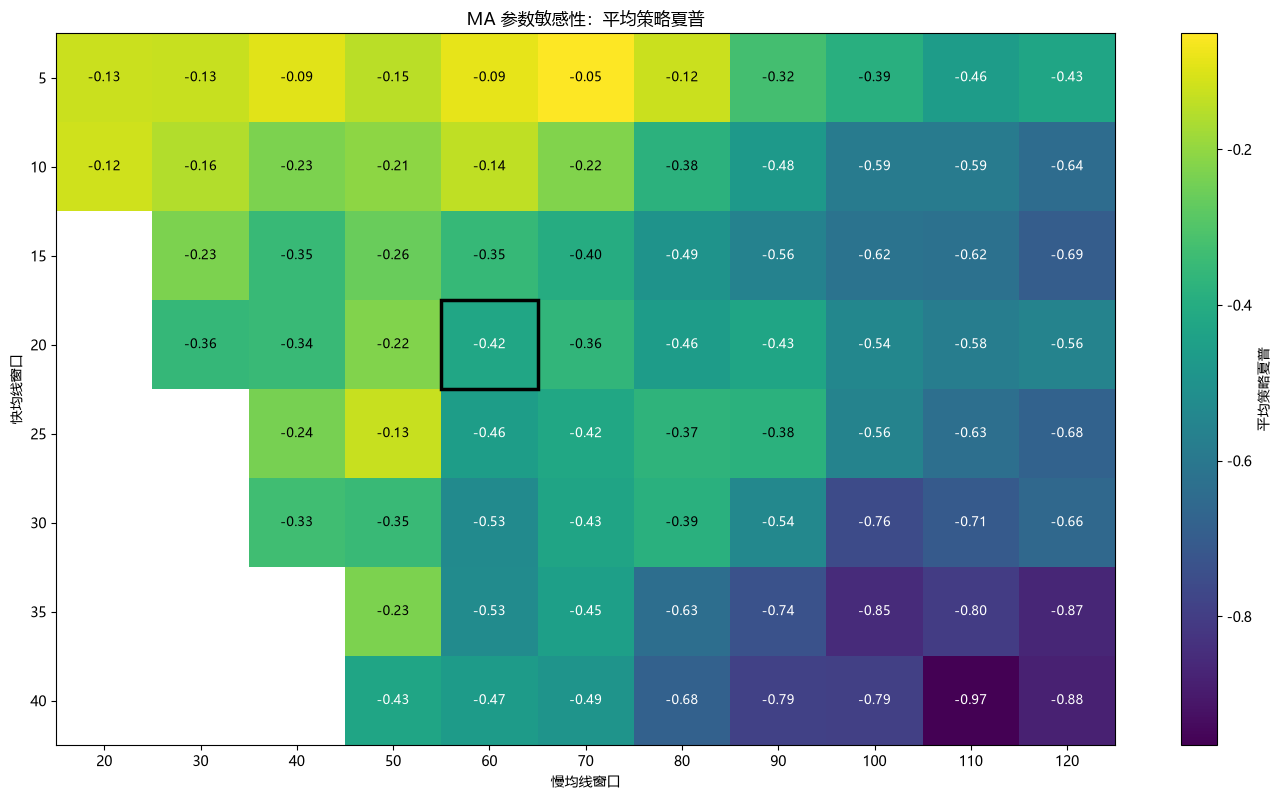

In [33]:
fig_sharpe, ax_sharpe = (
    plot_parameter_heatmap(
        parameter_summary=parameter_summary,
        metric="avg_strategy_sharpe",
        selected_parameter=existing_parameter,
        value_format=".2f",
        title="MA 参数敏感性：平均策略夏普",
    )
)

plt.show()

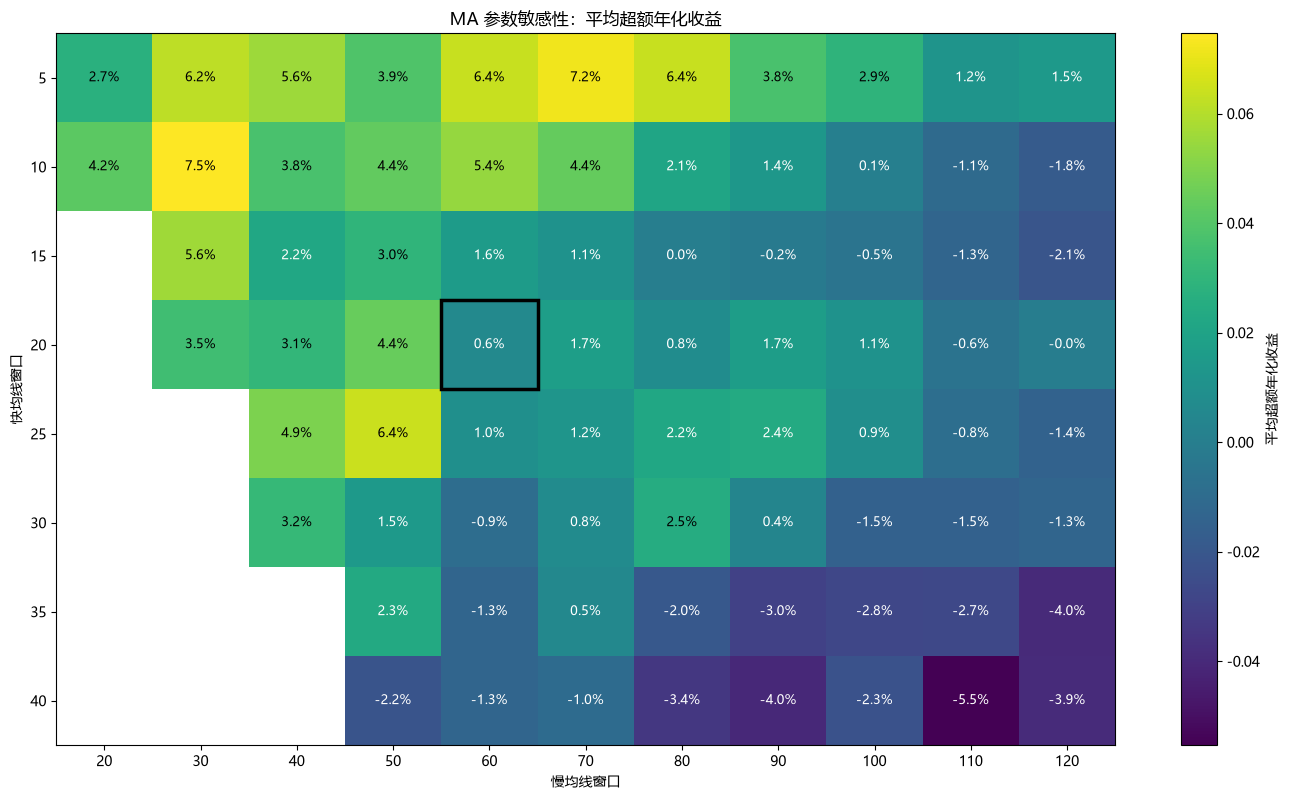

In [34]:
fig_excess_return, ax_excess_return = (
    plot_parameter_heatmap(
        parameter_summary=parameter_summary,
        metric="avg_excess_annual_return",
        selected_parameter=existing_parameter,
        value_format=".1%",
        title="MA 参数敏感性：平均超额年化收益",
    )
)

plt.show()

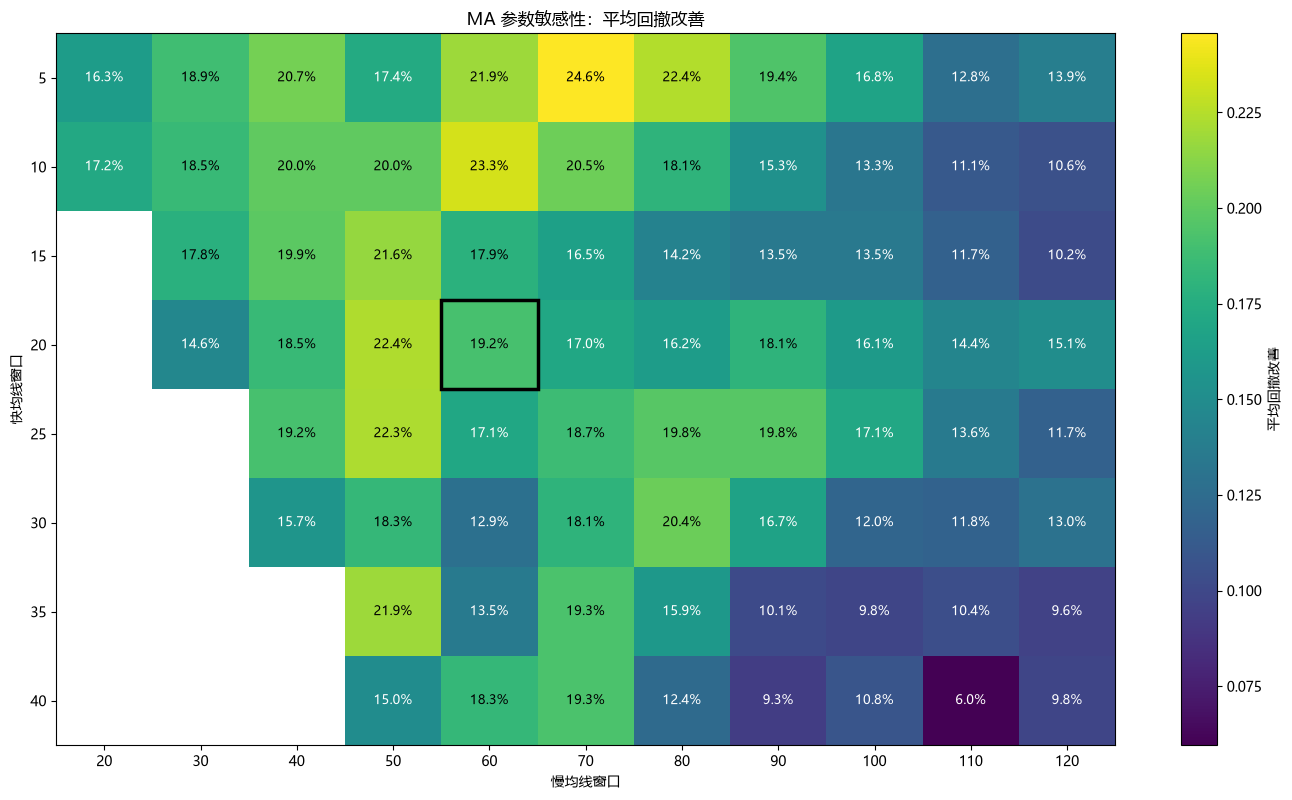

In [35]:
fig_drawdown, ax_drawdown = (
    plot_parameter_heatmap(
        parameter_summary=parameter_summary,
        metric="avg_drawdown_improvement",
        selected_parameter=existing_parameter,
        value_format=".1%",
        title="MA 参数敏感性：平均回撤改善",
    )
)

plt.show()

参数切片：固定快均线/慢均线，查看另一个参数变化时的策略变化

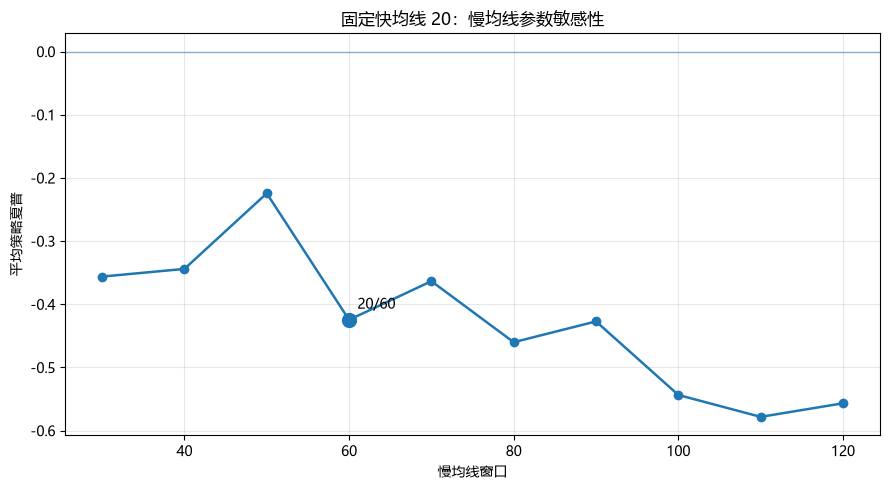

In [36]:
fig_fast_20, ax_fast_20 = (
    plot_parameter_slice(
        parameter_summary=parameter_summary,
        metric="avg_strategy_sharpe",
        fixed_parameter="fast",
        fixed_value=20,
        selected_parameter=existing_parameter,
        title="固定快均线 20：慢均线参数敏感性",
    )
)

plt.show()

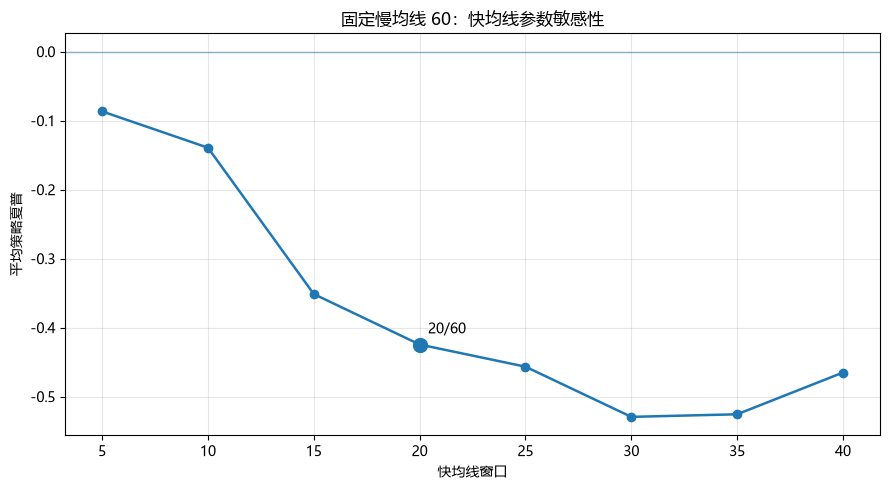

In [37]:
fig_slow_60, ax_slow_60 = (
    plot_parameter_slice(
        parameter_summary=parameter_summary,
        metric="avg_strategy_sharpe",
        fixed_parameter="slow",
        fixed_value=60,
        selected_parameter=existing_parameter,
        title="固定慢均线 60：快均线参数敏感性",
    )
)

plt.show()

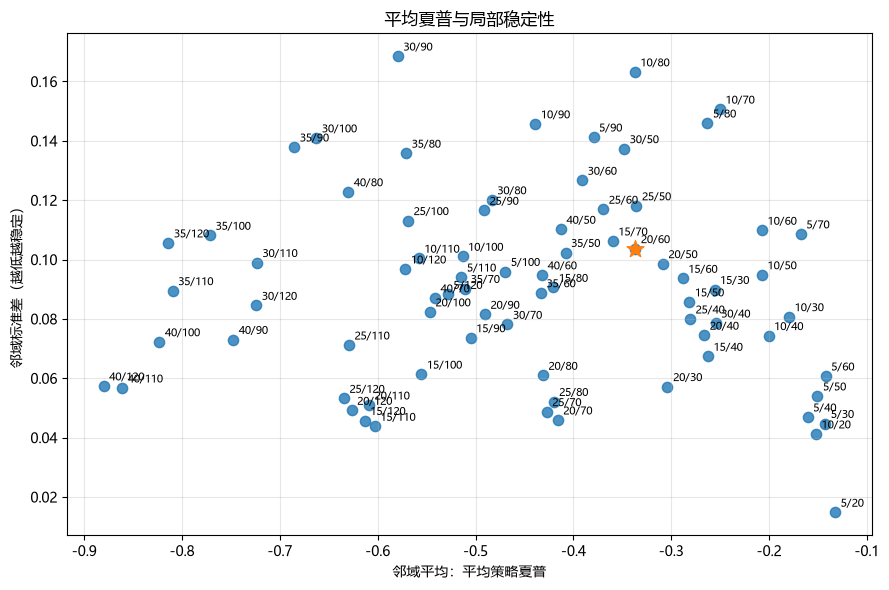

In [38]:
fig_stability, ax_stability = (
    plot_performance_stability(
        robustness_summary=robustness_summary,
        selected_parameter=existing_parameter,
        title="平均夏普与局部稳定性",
    )
)

plt.show()

In [39]:
robust_fast, robust_slow = robust_parameter

robust_parameter_detail = grid_detail.loc[
    (
        grid_detail["fast_window"]
        == robust_fast
    )
    & (
        grid_detail["slow_window"]
        == robust_slow
    )
].copy()

detail_columns = [
    "symbol",
    "fast_window",
    "slow_window",
    "strategy_annual_return",
    "excess_annual_return",
    "strategy_sharpe",
    "sharpe_diff",
    "strategy_max_drawdown",
    "drawdown_improvement",
    "exposure",
    "total_trade_count",
    "total_transaction_cost",
]

display(
    robust_parameter_detail[
        detail_columns
    ].sort_values(
        "strategy_sharpe",
        ascending=False,
    )
)

,symbol,fast_window,slow_window,strategy_annual_return,excess_annual_return,strategy_sharpe,sharpe_diff,strategy_max_drawdown,drawdown_improvement,exposure,total_trade_count,total_transaction_cost
67,300750,10,40,0.2377,0.1122,0.8114,0.3258,-0.3350,0.2937,0.5027,21,0.0105
68,600036,10,40,-0.0589,-0.0352,-0.2297,-0.2945,-0.2615,0.2478,0.4381,37,0.0185
69,600519,10,40,-0.0823,-0.0280,-0.4986,-0.4452,-0.2812,0.1173,0.4187,25,0.0125
65,000001,10,40,-0.1226,0.0057,-0.6121,-0.2939,-0.4741,0.1490,0.3617,29,0.0145
66,000002,10,40,-0.1646,0.1331,-0.6363,0.0825,-0.5833,0.1934,0.2960,26,0.0130


In [40]:
comparison_detail = grid_detail.loc[
    (
        (
            grid_detail["fast_window"]
            == existing_parameter[0]
        )
        & (
            grid_detail["slow_window"]
            == existing_parameter[1]
        )
    )
    |
    (
        (
            grid_detail["fast_window"]
            == robust_parameter[0]
        )
        & (
            grid_detail["slow_window"]
            == robust_parameter[1]
        )
    )
].copy()

comparison_detail["ma_param"] = (
    comparison_detail["fast_window"]
    .astype(str)
    + "/"
    + comparison_detail["slow_window"]
    .astype(str)
)

display(
    comparison_detail[
        [
            "symbol",
            "ma_param",
            "strategy_annual_return",
            "excess_annual_return",
            "strategy_sharpe",
            "strategy_max_drawdown",
            "drawdown_improvement",
            "total_trade_count",
        ]
    ].sort_values(
        [
            "symbol",
            "ma_param",
        ]
    )
)

,symbol,ma_param,strategy_annual_return,excess_annual_return,strategy_sharpe,strategy_max_drawdown,drawdown_improvement,total_trade_count
65,000001,10/40,-0.1226,0.0057,-0.6121,-0.4741,0.1490,29
175,000001,20/60,-0.0582,0.0634,-0.2697,-0.2478,0.3754,19
66,000002,10/40,-0.1646,0.1331,-0.6363,-0.5833,0.1934,26
176,000002,20/60,-0.2707,0.0226,-1.5161,-0.6872,0.0655,20
67,300750,10/40,0.2377,0.1122,0.8114,-0.3350,0.2937,21
177,300750,20/60,0.1375,0.0209,0.5586,-0.3713,0.2575,15
68,600036,10/40,-0.0589,-0.0352,-0.2297,-0.2615,0.2478,37
178,600036,20/60,-0.1149,-0.0930,-0.6246,-0.4281,0.0812,25
69,600519,10/40,-0.0823,-0.0280,-0.4986,-0.2812,0.1173,25
179,600519,20/60,-0.0514,0.0166,-0.2712,-0.2194,0.1792,18


In [41]:
REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("报告目录已准备：", REPORT_DIR)

grid_detail.to_csv(
    REPORT_DIR
    / "ma_sensitivity_in_sample_detail.csv",
    index=False,
    encoding="utf-8-sig",
)

parameter_summary.to_csv(
    REPORT_DIR
    / "ma_sensitivity_parameter_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

robustness_summary.to_csv(
    REPORT_DIR
    / "ma_sensitivity_robustness_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

parameter_comparison.to_csv(
    REPORT_DIR
    / "ma_parameter_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

print("CSV 结果保存完成")

报告目录已准备： e:\quant-learning\reports\ma_parameter_sensitivity
CSV 结果保存完成


In [42]:
fig_sharpe.savefig(
    REPORT_DIR
    / "heatmap_avg_strategy_sharpe.png",
    dpi=160,
    bbox_inches="tight",
)

fig_excess_return.savefig(
    REPORT_DIR
    / "heatmap_avg_excess_return.png",
    dpi=160,
    bbox_inches="tight",
)

fig_drawdown.savefig(
    REPORT_DIR
    / "heatmap_avg_drawdown_improvement.png",
    dpi=160,
    bbox_inches="tight",
)

fig_fast_20.savefig(
    REPORT_DIR
    / "slice_fast_20_avg_sharpe.png",
    dpi=160,
    bbox_inches="tight",
)

fig_slow_60.savefig(
    REPORT_DIR
    / "slice_slow_60_avg_sharpe.png",
    dpi=160,
    bbox_inches="tight",
)

fig_stability.savefig(
    REPORT_DIR
    / "performance_stability.png",
    dpi=160,
    bbox_inches="tight",
)

print("图片保存完成")

图片保存完成


In [44]:
best_point_parameter = (
    parameter_summary.sort_values(
        "avg_strategy_sharpe",
        ascending=False,
    )
    .iloc[0]
)

print(
    "平均夏普最高参数：",
    best_point_parameter["ma_param"],
)

print(
    "平均夏普：",
    best_point_parameter[
        "avg_strategy_sharpe"
    ],
)

print(
    "稳健候选参数：",
    f"{robust_parameter[0]}/{robust_parameter[1]}",
)

print(
    "原有参数：",
    f"{existing_parameter[0]}/{existing_parameter[1]}",
)

平均夏普最高参数： 5/70
平均夏普： -0.05100532157724265
稳健候选参数： 10/40
原有参数： 20/60


## 参数敏感性分析结论

### 1. 参数曲面形状

* 本轮单点平均夏普表现较高的参数为 `25/50`。
* 高表现参数没有形成明显连续平台。
* 参数曲面存在局部峰值，单点最优结果可能具有一定偶然性。
* 按照当前参数范围，`25/50` 不属于外部边界参数，但其周围结果不够连续，因此仍需谨慎解释。
* 当前参数曲面尚不足以支持直接确定最终参数。

### 2. 现有参数 20/60

* `20/60` 不位于本轮高表现区域。
* 其邻域平均夏普为 `-0.3367`，邻域标准差为 `0.1036`。
* `20/60` 自身平均夏普低于邻域平均值，`point_minus_local_mean=-0.0879`，因此它不是局部峰值。
* `20/60` 的优势是超额收益胜率较高，为 80%，并且平均交易次数较少，为 19.4 次。
* 目前不再将 `20/60` 作为首选参数，但继续保留为后续比较基准。

### 3. 稳健候选参数 10/40

* 当前稳健性排序给出的候选参数为 `10/40`。
* 邻域平均夏普为 `-0.2623`。
* 邻域标准差为 `0.0545`。
* 邻域最差夏普为 `-0.3508`。
* 平均超额年化收益为 3.76%。
* 超额收益胜率为 60%。
* 平均交易次数为 27.6 次。

`10/40` 在平均夏普、最差股票表现和当前局部稳定性方面优于 `20/60`，但它位于参数网格边界，邻域不完整，因此当前的低局部标准差可能存在边界偏差。

### 4. 与 20/60 的比较

* 平均收益：`10/40` 更好。
* 收益中位数：`20/60` 更好。
* 超额收益胜率：`20/60` 更好。
* 平均夏普：`10/40` 更好。
* 夏普中位数：`20/60` 更好。
* 最差股票表现：`10/40` 更好。
* 回撤改善：两者接近，`10/40` 略好。
* 当前局部稳定性：`10/40` 更好，但可能受到边界邻域不完整的影响。
* 交易频率：`10/40` 比 `20/60` 高约 42%，需要进一步考虑交易成本和策略复杂度。
* 跨股票一致性：`10/40` 的离散程度较低，但只有 60% 的股票取得正超额收益，因此只能评价为一般，不能评价为非常稳定。

### 5. 当前决策

* 暂不选择最终参数。
* `20/60` 不再作为首选，但保留为基准参数。
* `10/40` 作为下一轮重点研究候选，但暂不确认其稳健性。
* 下一轮扩大快均线和慢均线的下边界，补充 `10/40` 左侧和下侧缺失的参数。
* 在找到连续稳定平台之前，不进入正式样本外确认。
* 扩展网格后，应优先选择具有完整邻域的参数点进行稳健性排序，避免边界参数因邻居较少而获得偏高评价。


## 参数敏感性分析最终结论

扩展参数网格后，`10/40` 仍然是当前参数空间内稳健性表现最好的参数。

`10/40` 的平均策略夏普为 `-0.2330`，邻域平均夏普为 `-0.2004`，邻域标准差为 `0.0744`，稳健性分数为 `-0.2748`。其自身表现略低于邻域平均值，`point_minus_local_mean=-0.0326`，说明它不是孤立的局部尖峰，其优势主要来自周围参数区域整体表现较好。

与原参数 `20/60` 相比，`10/40` 在平均夏普、夏普标准差、最差股票夏普、平均超额收益、最差超额收益、回撤改善和局部稳定性方面均表现更好。其不足是超额收益胜率和收益中位数低于 `20/60`，平均交易次数也从 `19.4` 次增加到 `27.6` 次。

因此，当前将 `10/40` 确定为样本内主要稳健候选参数，将 `20/60` 保留为基准对照参数。由于 `10/40` 的平均夏普、中位夏普和邻域平均夏普仍然为负，当前结论只能说明它是已测试参数中的相对稳健候选，不能证明策略已经具备良好的绝对风险调整后收益。

参数敏感性分析阶段至此结束。下一阶段进入滚动窗口验证与 Walk-Forward Analysis，重点检验 `10/40` 及其邻近参数区域是否能在不同历史时期重复保持稳定表现。
